In [1]:
import numpy as np
import matplotlib.pyplot as plt

from delta_sigma_simulator.modulator import DeltaSigmaModulator
from delta_sigma_simulator.filter import FilterIntegrator, FilterButterworth, FilterUnit
from delta_sigma_simulator.quantizer import QuantizerDelayHysteresis, QuantizerClock
from delta_sigma_simulator.wave import BinaryWave, SineWave

In [2]:
def get_spectrum(v, fs, w=None):
    if w is not None:
        w = w(len(v))
    else:
        w = np.ones(len(v))

    w1 = np.linalg.norm(w, 1)

    f = np.fft.rfftfreq(len(v), d=1 / fs)
    V = np.fft.rfft(w * v) / (w1 / 2)

    return f, V

In [3]:
# - Period count
nu = 4
# - Input frequency
fu = 1e-2
# - Carrier frequency
f0 = 1e+0
# - Bandwidth frequency
fb = 16 * f0
# - Sampling frequency
fs = 16 * fb

# - Sine wave input
u = SineWave([0, 0.1], fu)
# - Binary wave input
wt = BinaryWave(np.arange(0, (nu + 2) / fu, 0.5 / f0))
# - Input Filter
G = FilterIntegrator(4 * f0)
# - Output Filter
H = FilterButterworth(10, fb)
# - Triangle wave input
w = G(wt)
# - Error
def y(t):
    return u(t) - w(t) + 1
# - Quantizer
q = QuantizerDelayHysteresis()
q.t_step = 1 / 10 / f0

In [4]:
run = True

t  = 0.0

v = BinaryWave([t])

while run:
    t += q.next(lambda dt: y(t + dt))

    v.append(t)

    if t > (nu + 1) / fu:
        run = False

In [5]:
t = np.arange(1 / fu, (nu + 1) / fu - 0.5 / fs, 1 / fs)

f, V = get_spectrum(H(v)(t), fs)

V_mask = 20 * np.log10(np.abs(V)) > -100

V_mask = (
    V_mask |
    np.r_[V_mask[1:], False] |   # left neighbor
    np.r_[False, V_mask[:-1]]    # right neighbor
)

C:\Users\Carom\Documents\GitHub\delta-sigma-simulator\delta_sigma_simulator\filter.py:40: RuntimeWarning: overflow encountered in exp
  self.residues[:, None] * self.p[:, None] ** n * np.exp(self.p[:, None] * t),
C:\Users\Carom\Documents\GitHub\delta-sigma-simulator\delta_sigma_simulator\filter.py:40: RuntimeWarning: overflow encountered in multiply
  self.residues[:, None] * self.p[:, None] ** n * np.exp(self.p[:, None] * t),
C:\Users\Carom\Documents\GitHub\delta-sigma-simulator\delta_sigma_simulator\filter.py:40: RuntimeWarning: invalid value encountered in multiply
  self.residues[:, None] * self.p[:, None] ** n * np.exp(self.p[:, None] * t),
C:\Users\Carom\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Carom\AppData\Local\Packages\PythonSoftwareFoundation.Python.

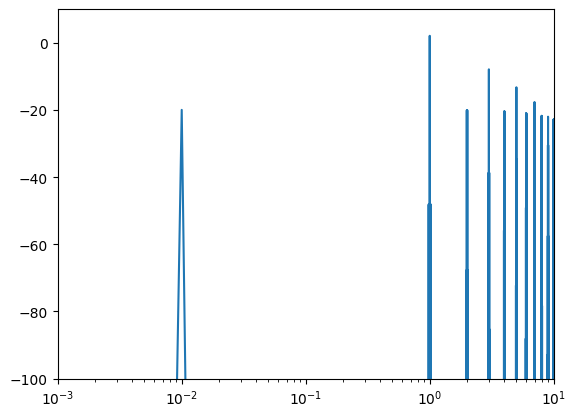

In [6]:
plt.semilogx(f[V_mask], 20 * np.log10(np.abs(V[V_mask])), color='C0')
plt.xlim(1e-3, 1e1)
plt.ylim(-100, 10)

np.savetxt("magic-pwm-frequency.csv", np.c_[f[V_mask], 20 * np.log10(np.abs(V[V_mask]))], delimiter=",", header="Frequency [Hz],Magnitude [dBFS]", comments="")

In [7]:
# - Period count
nu = 4
# - Input frequency
fu = 1e-1
# - Carrier frequency
f0 = 1e+0
# - Bandwidth frequency
fb = 16 * f0
# - Sampling frequency
fs = 16 * fb

# - Sine wave input
u = SineWave([0, 0.5 * np.exp(-1j * np.pi / 2)], fu)
# - Binary wave input
wt = BinaryWave(np.arange(0, (nu + 2) / fu, 0.5 / f0))
# - Input Filter
G = FilterIntegrator(4 * f0)
# - Triangle wave input
w = G(wt)
# - Error
def y(t):
    return u(t) - w(t) + 1
# - Quantizer
q = QuantizerDelayHysteresis()
q.t_step = 1 / 10 / f0

In [8]:
run = True

t  = 0.0

v = BinaryWave([t])

while run:
    t += q.next(lambda dt: y(t + dt))

    v.append(t)

    if t > (nu + 1) / fu:
        run = False

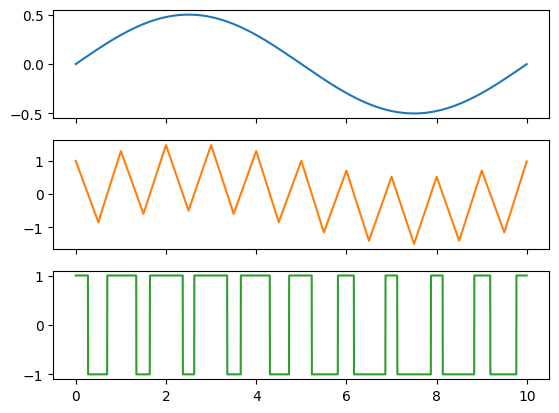

In [9]:
fig, ax = plt.subplots(3, 1, sharex=True)

t = np.arange(1 / fu, 2 / fu - 0.5 / fs, 1 / fs)

ax[0].plot(t - 1 / fu, u(t), label='u', color='C0')
ax[1].plot(t - 1 / fu, y(t), label='y', color='C1')
ax[2].plot(t - 1 / fu, v(t), label='v', color='C2')

np.savetxt("magic-pwm-time.csv", np.c_[t - 1 / fu, u(t), y(t), v(t)], delimiter=",", header="Time [s],Input [V],Error [V],Quantizer Output [V]", comments="")

In [10]:
# - Period count
nu = 4
# - Input frequency
fu = 1e-2
# - Carrier frequency
f0 = 1e+0
# - Bandwidth frequency
fb = 16 * f0
# - Sampling frequency
fs = 16 * fb

# - Sine wave input
u = SineWave([0, 0.1], fu)
# - Input Filter
G = FilterIntegrator(4 * f0)
# - Output Filter
H = FilterButterworth(10, fb)
# - Quantizer
q = QuantizerDelayHysteresis(v_s=1)
q.t_step = 1 / 10 / f0
# - ASDM
asdm = DeltaSigmaModulator(G, q)
# - Simulate
v = asdm.simulate(u, (nu + 1) / fu)

In [11]:
t = np.arange(1 / fu, (nu + 1) / fu - 0.5 / fs, 1 / fs)

f, V = get_spectrum(H(v)(t), fs)

V_mask = 20 * np.log10(np.abs(V)) > -100

V_mask = (
    V_mask |
    np.r_[V_mask[1:], False] |   # left neighbor
    np.r_[False, V_mask[:-1]]    # right neighbor
)

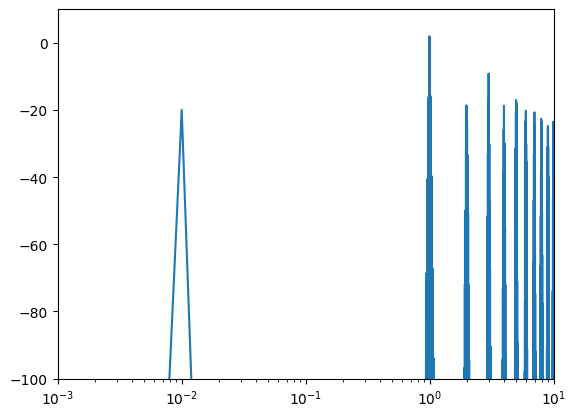

In [12]:
plt.semilogx(f[V_mask], 20 * np.log10(np.abs(V[V_mask])), color='C0')
plt.xlim(1e-3, 1e1)
plt.ylim(-100, 10)

np.savetxt("magic-asdm-frequency.csv", np.c_[f[V_mask], 20 * np.log10(np.abs(V[V_mask]))], delimiter=",", header="Frequency [Hz],Magnitude [dBFS]", comments="")

In [ ]:
# - Period count
nu = 4
# - Input frequency
fu = 1e-1
# - Carrier frequency
f0 = 1e+0
# - Bandwidth frequency
fb = 16 * f0
# - Sampling frequency
fs = 16 * fb

# - Sine wave input
u = SineWave([0, 0.5 * np.exp(-1j * np.pi / 2)], fu)
# - Input Filter
G = FilterIntegrator(4 * f0)
# - Output Filter
H = FilterButterworth(10, fb)
# - Quantizer
q = QuantizerDelayHysteresis(v_s=1)
q.t_step = 1 / 10 / f0
# - ASDM
asdm = DeltaSigmaModulator(G, q)
# - Simulate
v = asdm.simulate(u, (nu + 1) / fu)

In [ ]:
fig, ax = plt.subplots(3, 1, sharex=True)

t = np.arange(1 / fu, 2 / fu - 0.5 / fs, 1 / fs)

ax[0].plot(t - 1 / fu, u(t), label='u', color='C0')
ax[1].plot(t - 1 / fu, -asdm.y_v(t) + asdm.y_u[0](t), label='y', color='C1')
ax[2].plot(t - 1 / fu, v(t), label='v', color='C2')

np.savetxt("magic-asdm-time.csv", np.c_[t - 1 / fu, u(t), -asdm.y_v(t) + asdm.y_u[0](t), v(t)], delimiter=",", header="Time [s],Input [V],Error [V],Quantizer Output [V]", comments="")

In [ ]:
# - Period count
nu = 128
# - Input frequency
fu = 1e-2
# - Sampling frequency
f0 = 1e+0

# - Sine wave input
u = SineWave([0, 2 * np.pi * np.exp(-1j * np.pi / 2)], fu)
# - Input Filter
G = FilterIntegrator(4 * f0)
# - Quantizer
quantizer = QuantizerClock(f0, 4)
# - Modulator
modulator = DeltaSigmaModulator(h_u=FilterUnit(), h_v=G, q=quantizer)
# - Output
v = modulator.simulate(u, (nu + 4) / fu)

In [ ]:
t = np.arange(4 / fu, (nu + 4) / fu - 0.5 / f0, 1 / f0)

f, V = get_spectrum(v(t), f0)
f, V_int = get_spectrum(np.cumsum(v(t)) / f0, f0)

C:\Users\Carom\AppData\Local\Temp\ipykernel_9728\1558460423.py:6: RuntimeWarning: divide by zero encountered in log10
  plt.semilogx(f, 20 * np.log10(np.abs(V)), color='C0')
C:\Users\Carom\AppData\Local\Temp\ipykernel_9728\1558460423.py:10: RuntimeWarning: divide by zero encountered in log10
  np.savetxt("magic-dm-frequency.csv", np.c_[f, 20 * np.log10(np.abs(V)), 20 * np.log10(np.abs(V_int))], delimiter=",", header="Frequency [Hz],Magnitude [dBFS],Magnitude Int [dBFS]", comments="")


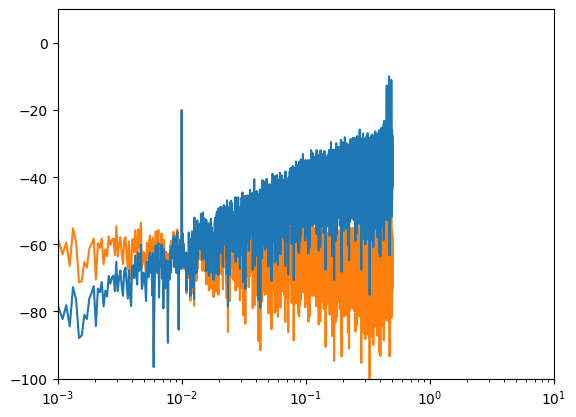

In [ ]:
gain = np.abs(V[np.argmin(np.abs(f - fu))]) / np.abs(V_int[np.argmin(np.abs(f - fu))])

V_int *= gain

plt.semilogx(f, 20 * np.log10(np.abs(V_int)), color='C1')
plt.semilogx(f, 20 * np.log10(np.abs(V)), color='C0')
plt.xlim(1e-3, 1e1)
plt.ylim(-100, 10)

np.savetxt("magic-dm-frequency.csv", np.c_[f, 20 * np.log10(np.abs(V)), 20 * np.log10(np.abs(V_int))], delimiter=",", header="Frequency [Hz],Magnitude [dBFS],Magnitude Int [dBFS]", comments="")

In [ ]:
# - Period count
nu = 4
# - Input frequency
fu = 1e-1
# - Sampling frequency
f0 = 1e+0

# - Sine wave input
u = SineWave([0, 0.5 * np.exp(-1j * np.pi / 2)], fu)
# - Input Filter
G = FilterIntegrator(4 * f0)
# - Quantizer
quantizer = QuantizerClock(f0, 4)
# - Modulator
modulator = DeltaSigmaModulator(h_u=FilterUnit(), h_v=G, q=quantizer)
# - Output
v = modulator.simulate(u, (nu + 4) / fu)

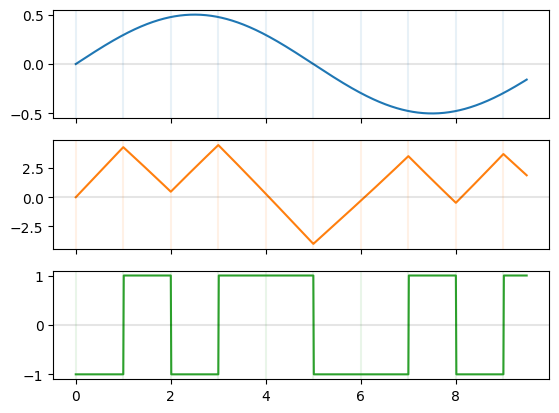

In [ ]:
fig, ax = plt.subplots(3, 1, sharex=True)

t = np.arange(1 / fu, 2 / fu - 0.5 / f0, 1 / 100 / f0)

ax[0].plot(t - 1 / fu, u(t), label='u', color='C0')
ax[1].plot(t - 1 / fu, -modulator.y_v(t) + modulator.y_u[0](t), label='y', color='C1')
ax[2].plot(t - 1 / fu, v(t), label='v', color='C2')

ax[0].axhline(0, color='k', alpha=0.1)
ax[1].axhline(0, color='k', alpha=0.1)
ax[2].axhline(0, color='k', alpha=0.1)

for i in range(10):
    ax[0].axvline(i / f0, color='C0', alpha=0.1)
    ax[1].axvline(i / f0, color='C1', alpha=0.1)
    ax[2].axvline(i / f0, color='C2', alpha=0.1)

np.savetxt("magic-dm-time.csv", np.c_[t - 1 / fu, u(t), -modulator.y_v(t) + modulator.y_u[0](t), v(t)], delimiter=",", header="Time [s],Input [V],Error [V],Quantizer Output [V]", comments="")